# Notebook uniqid tb Custom Table of Contents (Appendix)

##  👉️Work 1

### As part of the modularization process, we first create a program code file in Work 1.

Work1 creates toc_generator.py. See image.

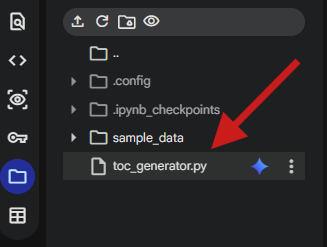





In [225]:
import hashlib
import os
import IPython
import json
from google.colab import _message
from IPython.display import display, HTML

# Modularized TOC Generator Logic with ID Recovery Hint
toc_generator_code = r'''
import hashlib
import os
import IPython
import json
from google.colab import _message
from IPython.display import display, HTML

def _get_notebook_cells():
    resp = _message.blocking_request("get_ipynb")
    if not resp or "ipynb" not in resp:
        print("Failed to get notebook structure.")
        return None
    return resp["ipynb"].get("cells", [])

def _extract_heading_preview(source, cell_type, limit):
    text = "".join(source) if isinstance(source, list) else str(source)
    text = text.strip().replace("\n", " ")
    if cell_type == "markdown" and text.startswith("#"):
        cleaned = text.lstrip("#").strip()
        if not cleaned: return "(Empty heading)"
        return f"**{cleaned[:limit]}**" if len(cleaned) > limit else f"**{cleaned}**"
    return f"{text[:limit]}..." if len(text) > limit else text

def set_toc_len(new_len):
    ip = IPython.get_ipython()
    ip.db["colab_toc_max_len"] = int(new_len)
    print(f"Display length set to {new_len}.")

def generate_advanced_toc(filter_type="All", keyword="", show_stats=True, strict_id_match=False, show_jump_links=True, save_log=False):
    ip = IPython.get_ipython()
    stored_limit = ip.db.get("colab_toc_max_len", 30)
    cells = _get_notebook_cells()
    if not cells: return

    # Improved ID extraction: checking multiple possible metadata fields
    ids = []
    unknown_detected = False
    for c in cells:
        meta = c.get('metadata', {})
        cid = meta.get('colab', {}).get('id') or c.get('id') or meta.get('id') or 'unknown'
        if cid == 'unknown': unknown_detected = True
        ids.append(str(cid))

    if unknown_detected:
        print("💡 Hint: Some Cell IDs are 'unknown'. Please press Ctrl+S to save the notebook and refresh IDs.")

    max_id_len = max([len(i) for i in ids]) if ids else 12

    jump_base = "[Jump](#scrollTo=)"
    w_jump = max(len("Jump Link"), max_id_len + len(jump_base))
    w_id = max(len("Cell ID"), max_id_len + 2)

    h_jump = f" {('Jump Link').ljust(w_jump)} |" if show_jump_links else ""
    s_jump = f" {(':---').ljust(w_jump, '-')} |" if show_jump_links else ""
    header = f"| Type | Index |{h_jump} {('Cell ID').ljust(w_id)} | Heading / Preview |"
    sep = f"| :--- | :--- |{s_jump} {(':---').ljust(w_id, '-')} | :--- |"

    md_table = ["# TOC Preview. Quick Navigation", f"Filter: `{filter_type}`, Mode: `{'ID' if strict_id_match else 'Content'}`", header, sep]
    match_count = 0

    for idx, cell in enumerate(cells):
        c_type = cell.get("cell_type", "unknown")
        if "All" not in str(filter_type):
            if "Code" in filter_type and c_type != "code": continue
            if "Text" in filter_type and c_type != "markdown": continue

        cell_id = ids[idx]
        source = "".join(cell.get("source", ""))
        if keyword:
            if strict_id_match and keyword != cell_id: continue
            elif not strict_id_match and keyword.lower() not in source.lower(): continue

        match_count += 1
        preview = _extract_heading_preview(source, c_type, stored_limit)
        icon = "MD" if c_type == "markdown" else "Code"
        row = f"| {icon} | {idx:03d} |"
        if show_jump_links: row += f" {f'[Jump](#scrollTo={cell_id})'.ljust(w_jump)} |"
        row += f" {f'`{cell_id}`'.ljust(w_id)} | {preview} |"
        md_table.append(row)

    full_md = "\n".join(md_table)
    if save_log:
        with open("TOC Preview.md", "w", encoding="utf-8", errors="replace") as f: f.write(full_md)
    if show_stats: print(f"Total {len(cells)} cells | Found {match_count} matches.")

    js_md = json.dumps(full_md)
    btn_html = """<div style='margin: 15px 0;'><button id='copy_btn_mod' style='background: #4285f4; color: white; padding: 10px 20px; border: none; border-radius: 4px; cursor: pointer; font-weight: bold;'>Copy TOC to Clipboard</button></div><script>(function(){ const btn = document.getElementById('copy_btn_mod'); btn.onclick = function(){ const text = """ + js_md + """; navigator.clipboard.writeText(text).then(() => { btn.innerText = 'Copied!'; btn.style.background = '#34a853'; setTimeout(() => { btn.innerText = 'Copy TOC to Clipboard'; btn.style.background = '#4285f4'; }, 2000); }); }; })();</script>"""
    display(HTML(btn_html))
    print("\n" + full_md)
'''

with open('toc_generator.py', 'w', encoding='utf-8') as f:
    f.write(toc_generator_code.strip())
print('toc_generator.py updated with ID recovery logic. Please save the notebook (Ctrl+S) then re-run Work 1 and 2.')

toc_generator.py updated with ID recovery logic. Please save the notebook (Ctrl+S) then re-run Work 1 and 2.


## 👉️Work 2: Generate a table of contents for cell IDs. Import & Execute the Modularized Code

Option Set the number of characters for the preview as needed (e.g., 70 characters).



In [226]:
# @title 🔎 TOC Generate Panel { run: "auto" }

import importlib
import toc_generator

# Force reload to ensure the SyntaxError fix in Work 1 is applied
importlib.reload(toc_generator)

# @markdown ---
# @markdown   ### 🔍 Setting. Normally, you don't need to change the settings.
Filter_Type = "All (Code & Text)" # @param ["All (Code & Text)", "Code", "Text (Markdown)"]
Keyword_Search = "" # @param {type:"string"}
Match = "Cell-ID" # @param ["Cell-ID","Cell-contents"]

# @markdown ---
# @markdown ### 📏 Layout Settings
Show_Jump_Links = True # @param {type:"boolean"}
Show_Stats = True # @param {type:"boolean"}
Save_Preview_Log = True # @param {type:"boolean"}
# @markdown Displays the number of code cells and text cells.
Preview_Length = 100 # @param {type:"slider", min:10, max:150, step:5}

# Logic conversion
strict_id_match_bool = (Match == "Cell-ID")

# Apply & Run
toc_generator.set_toc_len(Preview_Length)
toc_generator.generate_advanced_toc(
    filter_type=Filter_Type,
    keyword=Keyword_Search,
    show_stats=Show_Stats,
    strict_id_match=strict_id_match_bool,
    show_jump_links=Show_Jump_Links,
    save_log=Save_Preview_Log
)

Display length set to 100.
Total 12 cells | Found 12 matches.



# TOC Preview. Quick Navigation
Filter: `All (Code & Text)`, Mode: `ID`
| Type | Index | Jump Link                      | Cell ID        | Heading / Preview |
| :--- | :--- | :----------------------------- | :------------- | :--- |
| MD | 000 | [Jump](#scrollTo=KGkcDF5ZFOo7) | `KGkcDF5ZFOo7` | **Notebook uniqid tb Custom Table of Contents (Appendix)** |
| MD | 001 | [Jump](#scrollTo=Dybev4-VcXMq) | `Dybev4-VcXMq` | **👉️Work 1** |
| MD | 002 | [Jump](#scrollTo=bb2afd34)     | `bb2afd34`     | **As part of the modularization process, we first create a program code file in Work 1.  Work1 creates** |
| Code | 003 | [Jump](#scrollTo=dHqDV532l9Uf) | `dHqDV532l9Uf` | import hashlib import os import IPython import json from google.colab import _message from IPython.d... |
| MD | 004 | [Jump](#scrollTo=aQEiOYtYcgyn) | `aQEiOYtYcgyn` | **👉️Work 2: Generate a table of contents for cell IDs. Import & Execute the Modularized Code  Option S** |
| Code | 005 | [Jump](#scrollTo=bfae0bec)     | `bfae0

# How to Use `toc_generator` in Another Colab Notebook

To use the `toc_generator.py` module in another Colab notebook, follow these steps:

1.  **Upload the `toc_generator.py` file**: Open a new Colab notebook, click the file icon (folder) on the left sidebar. Click the upload icon and select the `toc_generator.py` file you created in Work 1.

2.  **Import the module**:
    ```python
    import toc_generator
    ```

3.  **Configure Preview Length (Optional)**:
    You can set the maximum number of characters shown for each cell's preview. This setting is stored in your Colab environment settings.
    ```python
    toc_generator.set_toc_len(100) # Example: set to 100 characters
    ```

4.  **Generate the TOC**:
    Call the generator function. You can enable `save_log=True` to create local `.md` and `.html` preview files.
    ```python
    toc_generator.generate_advanced_toc(
        filter_type="All",
        keyword="",
        show_stats=True,
        strict_id_match=False,
        show_jump_links=True,
        save_log=True
    )
    ```

Alternatively, you can copy the code from the **STAND-ALONE** section into a single cell in any notebook for a fully interactive GUI experience without needing the external `.py` file.

## Resources

- [Google Colaboratory](https://colab.research.google.com/)
- [GitHub Markdown Guide](https://guides.github.com/features/mastering-markdown/)
- [Python Official Documentation](https://docs.python.org/3/)

## Colab Notebook Table of Contents Generator

## Why This Tool?
In Google Colaboratory, cell IDs can change or be difficult to track. This tool generates a stable Table of Contents (TOC) with precise alignment, making it easy to navigate large notebooks via jump links.

## Overview
This module generates a Markdown-formatted TOC. It calculates the maximum length of cell IDs and jump links to ensure the output table is perfectly aligned and readable.

## Features
*   **Dynamic Padding**: Automatically aligns columns based on the longest Cell ID.
*   **Jump Links**: Creates direct anchor links (`#scrollTo=`) to cells.
*   **Modular & Standalone**: Use it as a `.py` module or a single-cell script.
*   **Customizable**: Adjustable preview lengths via sliders or function arguments.

## Installation & Setup
1.  **Work 1**: Run the code to create `toc_generator.py`.
2.  **Work 2**: Import and execute the generator panel.

## Usage
```python
import toc_generator
toc_generator.generate_advanced_toc(save_log=True)
```

## Example Output (Current Version)
The current version produces a clean, aligned Markdown table where column widths adjust automatically to prevent layout breakage:

```markdown
# 🔍 TOC Preview. Quick Navigation
Mode: `Cell-ID`, Filter: `All`
| Type | Index | Jump Link                      | Cell ID        | Heading / Preview |
| :--- | :--- | :----------------------------- | :------------- | :--- |
| 📝 | 000 | [Jump](#scrollTo=KGkcDF5ZFOo7) | `KGkcDF5ZFOo7` | **Notebook Title** |
| 💻 | 001 | [Jump](#scrollTo=iZiVTOJEameD) | `iZiVTOJEameD` | print('Hello World')... |
```

## Resources
- [Google Colaboratory](https://colab.research.google.com/)
- [Markdown Table Generator Logic](https://github.com/adam-p/markdown-here/wiki/Markdown-Cheatsheet#tables)

In [ ]:
readme_content = '''# Cell ID Call: A Colab Table of Contents Generator

## Why This Tool?

In Google Colaboratory, cell IDs (the unique identifiers for each code or text cell) can change when you add, delete, or reorder cells. This often leads to broken anchor links in your Table of Contents, making it difficult to navigate within your notebook. This tool was developed to solve this problem by generating stable, persistent anchor links that continue to work even after modifications to your notebook structure, ensuring a smooth and reliable navigation experience. **Furthermore, a key objective of this tool is to present cell IDs in a manner that makes them immediately identifiable and understandable to human users, even when explained by an AI.**

## Overview

Cell ID Call is a Python module designed to generate a stable Markdown-formatted Table of Contents (TOC) for Google Colaboratory notebooks. It specifically addresses the dynamic nature of Colab environments where cell IDs can change, ensuring that the generated anchor links remain functional even after adding or deleting cells.

## Features

*   **Automatic TOC Generation**: Creates a Table of Contents from both Markdown and code cells within a Google Colab notebook.
*   **Stable Anchor Links**: Generates robust anchor links that maintain functionality even when cells are added or removed in the Colab environment.
*   **Customizable Preview Length**: Allows users to customize the length of heading previews displayed in the TOC.
*   **Backup Functionality**: Saves the generated TOC in Markdown format to a `notebook_toc_backup.md` file.
*   **Modular Design**: Can be easily imported and used as a module in any other Colab notebook.

## Installation & Setup

1.  **Download `toc_generator.py`**: Download the `toc_generator.py` file to your local machine.
2.  **Upload to Colab**: In your Google Colab notebook, click the folder icon (Files) on the left sidebar, then click the upload icon (up arrow). Select and upload the `toc_generator.py` file to your Colab runtime.

## Usage

Once the `toc_generator.py` file is uploaded to your Colab environment, you can use it in any notebook:

1.  **Import the module**: Whereas previously you used the generic 'toc_generator', for this project, you would import 'cell_id_call'.

    ```python
    import cell_id_call as toc_generator
    ```

2.  **Set TOC display length (optional)**:

    You can set the maximum length of the heading preview in the TOC. This setting will be persistently stored across Colab sessions.

    ```python
    toc_generator.set_toc_len(70) # Example: set to 70 characters
    ```

3.  **Generate the Table of Contents**:

    Call the main function to generate and print the TOC to the console. The output will include a Markdown table ready to be copied and pasted into a Markdown cell in your notebook.

    ```python
    toc_generator.generate_stable_markdown_toc()
    ```

## Example Output

When `toc_generator.generate_stable_markdown_toc()` is executed, it will print output similar to the following in your console:

```
======================= Paste into Md cell: Anchor link ===================
### 📑 Quick Navigation (All Cells)
Click each icon to jump directly to that cell.
| Type | Index | Cell ID | Heading |
| :--- | :--- | :--- | :--- |
| 📝 | [000](#scrollTo=KGkcDF5ZFOo7) | KGkcDF5ZFOo7 | Notebook uniqid tb Custom Table of Contents (Appendix) |
| 💻 | [001](#scrollTo=c10ad51e) | c10ad51e | (No heading) |
| ... (truncated for brevity) ... |
---
===========================================================================
======================= [👀 Plain Text Overview] ==========================
Index | Type | Cell ID          | Heading
------|------|------------------|----------------
000   | 📝  | KGkcDF5ZFOo7     | Notebook uniqid tb Custom Table of Contents (Appendix)
001   | 💻  | c10ad51e         | (No heading)
| ... (truncated for brevity) ... |
===========================================================================
======================= [👀 Current Environment Status] ===================
📂 Current Directory : /content
💾 TOC Saved File   : notebook_toc_backup.md (Markdown format)
⚙️ Stored Max Length: 70 chars (Configured)
===========================================================================
```

*(Note: The actual output will contain all your notebook cells and their respective information.)*

## Development Notes

This project's `toc_generator.py` source code is embedded within its own Colab notebook and generated dynamically. This approach simplifies development and ensures that the module's definition is always available within the working notebook, facilitating iterative changes and testing.

## Contributing

Contributions are welcome! If you have suggestions for improvements, bug reports, or new features, please open an issue or submit a pull request on GitHub.

## License

This project is licensed under the MIT License - see the [LICENSE](LICENSE) file for details.

## Resources

-   [Google Colaboratory](https://colab.research.google.com/)
-   [GitHub Markdown Guide](https://guides.github.com/features/mastering-markdown/)
-   [Python Official Documentation](https://docs.python.org/3/)'''

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme_content)

print("README.md has been created. You can download it from the file browser on the left.")

# STAND-ALONE

In [227]:
# @title 🔍 STAND-ALONE TOC Generator (Full-Featured & Improved Preview) { run: "auto" }

import IPython
import json
import os
from google.colab import _message
from IPython.display import display, HTML

# @markdown ### 🔍 Search Settings
Filter_Type = "All" # @param ["All", "Code", "Markdown"]
Keyword_Search = "" # @param {type:"string"}
Match_Mode = "Cell-ID" # @param ["Cell-ID", "Cell-contents"]

# @markdown ### 📏 Layout Settings
Preview_Length = 70 # @param {type:"slider", min:10, max:150, step:5}
Show_Jump_Links = True # @param {type:"boolean"}
Show_Stats = True # @param {type:"boolean"}
Save_Preview_Log = True # @param {type:"boolean"}

def _extract_heading_preview_standalone(source, cell_type, limit):
    text = "".join(source) if isinstance(source, list) else str(source)
    text = text.strip().replace("\n", " ")
    if cell_type == "markdown" and text.startswith("#"):
        cleaned = text.lstrip("#").strip()
        if not cleaned: return "(Empty heading)"
        return f"**{cleaned[:limit]}**" if len(cleaned) > limit else f"**{cleaned}**"
    return f"{text[:limit]}..." if len(text) > limit else text

def generate_standalone_toc(filter_type, keyword, match_mode, limit, show_jump, show_stats, save_log):
    resp = _message.blocking_request('get_ipynb')
    if not resp or 'ipynb' not in resp: return
    cells = resp['ipynb'].get('cells', [])

    # Precise ID and Alignment Logic
    processed_ids = []
    for c in cells:
        meta = c.get('metadata', {})
        cid = meta.get('colab', {}).get('id') or c.get('id') or meta.get('id') or "unknown"
        processed_ids.append(str(cid))

    max_id_len = max([len(cid) for cid in processed_ids]) if processed_ids else 12

    # Dynamic Column Width Calculation
    jump_link_base = "[Jump](#scrollTo=)"
    w_jump = max(len("Jump Link"), max_id_len + len(jump_link_base))
    w_id = max(len("Cell ID"), max_id_len + 2)

    h_jump = f" {('Jump Link').ljust(w_jump)} |" if show_jump else ""
    s_jump = f" {(':---').ljust(w_jump, '-')} |" if show_jump else ""

    header = f"| Type | Index |{h_jump} {('Cell ID').ljust(w_id)} | Heading / Preview |"
    sep = f"| :--- | :--- |{s_jump} {(':---').ljust(w_id, '-')} | :--- |"

    md_table = ["# 🔍 TOC Preview. Quick Navigation (Standalone)", f"Mode: `{match_mode}`, Filter: `{filter_type}`", header, sep]
    stats = {'markdown': 0, 'code': 0, 'total': len(cells)}
    match_count = 0

    for idx, cell in enumerate(cells):
        c_type = cell.get('cell_type', 'unknown')
        stats[c_type] = stats.get(c_type, 0) + 1
        if filter_type == "Code" and c_type != 'code': continue
        if filter_type == "Markdown" and c_type != 'markdown': continue

        cell_id = processed_ids[idx]
        source_text = "".join(cell.get('source', []))

        if keyword:
            if match_mode == "Cell-ID":
                if keyword != cell_id: continue
            else:
                if keyword.lower() not in source_text.lower(): continue

        match_count += 1
        preview = _extract_heading_preview_standalone(source_text, c_type, limit)
        icon = "📝" if c_type == 'markdown' else "💻"

        row = f"| {icon} | {idx:03d} |"
        if show_jump:
            row += f" {f'[Jump](#scrollTo={cell_id})'.ljust(w_jump)} |"

        row += f" {f'`{cell_id}`'.ljust(w_id)} | {preview} |"
        md_table.append(row)

    full_md = "\n".join(md_table)

    if save_log:
        with open("TOC Preview.md", "w", encoding="utf-8") as f: f.write(full_md)

    if show_stats: print(f"📊 Total: {stats['total']} | Matches: {match_count}")

    # UI Button with improved JS for copying
    js_content = json.dumps(full_md)
    button_id = "copy_btn_standalone"
    html_btn = f'''
    <div style="margin: 15px 0;">
        <button id="{button_id}" style="background: #1a73e8; color: white; padding: 10px 20px; border: none; border-radius: 4px; cursor: pointer; font-weight: bold;">
            📋 Copy TOC to Clipboard
        </button>
    </div>
    <script>
    (function() {{
        const btn = document.getElementById("{button_id}");
        if (!btn) return;
        btn.onclick = function() {{
            const text = {js_content};
            if (!navigator.clipboard) {{
               const textArea = document.createElement("textarea");
               textArea.value = text;
               document.body.appendChild(textArea);
               textArea.select();
               try {{ document.execCommand('copy'); }} catch (err) {{ }}
               document.body.removeChild(textArea);
            }} else {{
                navigator.clipboard.writeText(text).then(() => {{
                    const original = btn.innerText;
                    btn.innerText = "✅ Copied!";
                    btn.style.background = "#34a853";
                    setTimeout(() => {{
                        btn.innerText = original;
                        btn.style.background = "#1a73e8";
                    }}, 2000);
                }});
            }}
        }};
    }})();
    </script>
    '''
    display(HTML(html_btn))
    print("\n" + full_md)

generate_standalone_toc(Filter_Type, Keyword_Search, Match_Mode, Preview_Length, Show_Jump_Links, Show_Stats, Save_Preview_Log)

📊 Total: 12 | Matches: 12



# 🔍 TOC Preview. Quick Navigation (Standalone)
Mode: `Cell-ID`, Filter: `All`
| Type | Index | Jump Link                      | Cell ID        | Heading / Preview |
| :--- | :--- | :----------------------------- | :------------- | :--- |
| 📝 | 000 | [Jump](#scrollTo=KGkcDF5ZFOo7) | `KGkcDF5ZFOo7` | **Notebook uniqid tb Custom Table of Contents (Appendix)** |
| 📝 | 001 | [Jump](#scrollTo=Dybev4-VcXMq) | `Dybev4-VcXMq` | **👉️Work 1** |
| 📝 | 002 | [Jump](#scrollTo=bb2afd34)     | `bb2afd34`     | **As part of the modularization process, we first create a program code ** |
| 💻 | 003 | [Jump](#scrollTo=dHqDV532l9Uf) | `dHqDV532l9Uf` | import hashlib import os import IPython import json from google.colab ... |
| 📝 | 004 | [Jump](#scrollTo=aQEiOYtYcgyn) | `aQEiOYtYcgyn` | **👉️Work 2: Generate a table of contents for cell IDs. Import & Execute ** |
| 💻 | 005 | [Jump](#scrollTo=bfae0bec)     | `bfae0bec`     | # @title 🔎 TOC Generate Panel { run: "auto" }  import importlib import... |
| 📝 | 0